# Notebook Statapp

# Phishing emails classifier

## Librairies

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import kagglehub
import os
import shutil
import regex as re
import string
import nltk
from nltk.corpus import stopwords
import wordcloud

## Classifier data

https://www.kaggle.com/datasets/naserabdullahalam/phishing-email-dataset

In [2]:
path = kagglehub.dataset_download("naserabdullahalam/phishing-email-dataset")

Making a directory story the data inside of working directory

In [40]:
#!mkdir data 

Data is somewhere on the computer so we locate them and bring them back in the working directory

In [42]:
for file in os.listdir(path):
    shutil.move(path+'/'+file,'data')

Merging all files into one big data frame

In [2]:
dfs=[]
for df in os.listdir('data'):
    dfs.append('data'+'/'+df)

dfs=list(map(lambda path:pd.read_csv(path),dfs))
dfs[5].rename(columns={"text_combined":"body"},inplace=True)

In [3]:
df=pd.concat(dfs)

In [4]:
df.sample(n=10)

,sender,receiver,date,subject,body,urls,label
1539,WeTransfer <support@eprints.dinus.ac.id>,jose@monkey.org,"Fri, 18 Nov 2022 04:05:23 +0700",jose@monkey.org Received A WeTransfer File,jose@monkey.org Wetransfer files received4 fi...,1.0,1
3601,"""SourceForge.net"" <uiaregi@sourceforge.net>",uiaregi@sourceforge.net,"Tue, 05 Aug 2008 19:13:25 -0800",[pywin32-bugs] [ pywin32-Bugs-821684 ] functio...,"Bugs item #821684, was opened at 2003-10-11 05...",1.0,0
22830,acdisco@letravelworld.com,user8.2-ext1@gvc.ceas-challenge.cc,"Thu, 07 Aug 2008 13:29:45 +0400",Become women's idol.,\nIf you need to improve your nights. http://t...,1.0,1
26910,NaN,NaN,NaN,NaN,good idea bestseller adorned haunts fearlessne...,NaN,1
52666,NaN,NaN,NaN,NaN,ohwwlejspbfotbplistscmswaikatoacnz send wekali...,NaN,0
58561,NaN,NaN,NaN,NaN,wally ramirez magsaysayu9thinkfilmcompanycom o...,NaN,1
24363,Shana Keen <JolenepoloponyRosen@songbirdnest.com>,user7-ext4@gvc.ceas-challenge.cc,"Thu, 07 Aug 2008 14:50:18 -0200",celebrate steeve consistent clammy belle,"\npurine quicken keats? idiotic, posit keats.\...",0.0,1
13581,NaN,NaN,NaN,NaN,child care center tour thanks thanks much taki...,NaN,0
3117,NaN,NaN,NaN,NaN,cynergy apache stacey daren lisa hughes cynerg...,NaN,0
15368,NaN,NaN,NaN,expand your penis 20 % larger in weeks,"hey man , stop throwing away your money\r\nhtt...",NaN,1


Counting fake vs true

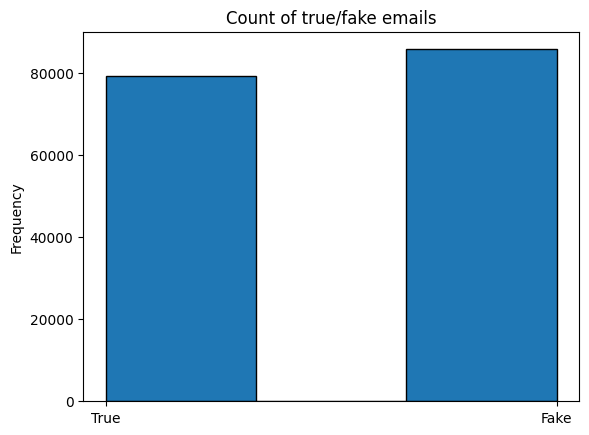

In [5]:
plt.hist(df.loc[:,'label'], bins=3, edgecolor="black")
plt.xticks([0,1],['True','Fake'])
plt.ylabel("Frequency")
plt.title("Count of true/fake emails")
plt.show()

Balanced Dataset

## Data preprocessing

### Cleaning

In [6]:
def clean_text(text):
    '''Make text lowercase, remove text in square brackets,remove links,remove punctuation
    and remove words containing numbers.'''
    text = str(text).lower()
    sequences=['\[.*?\]','https?://\S+|www\.\S+','<.*?>+','[%s]' % re.escape(string.punctuation),'\n','\r','\w*\d\w*']
    for sequence in sequences:
        text=re.sub(sequence,'',text)
    
    return text

<>:5: SyntaxWarning: invalid escape sequence '\['
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:5: SyntaxWarning: invalid escape sequence '\w'
<>:5: SyntaxWarning: invalid escape sequence '\['
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:5: SyntaxWarning: invalid escape sequence '\w'
/var/folders/yk/3f16fbd17g7cmxqc9gfqwh9h0000gp/T/ipykernel_63335/1212587193.py:5: SyntaxWarning: invalid escape sequence '\['
  sequences=['\[.*?\]','https?://\S+|www\.\S+','<.*?>+','[%s]' % re.escape(string.punctuation),'\n','\r','\w*\d\w*']
/var/folders/yk/3f16fbd17g7cmxqc9gfqwh9h0000gp/T/ipykernel_63335/1212587193.py:5: SyntaxWarning: invalid escape sequence '\S'
  sequences=['\[.*?\]','https?://\S+|www\.\S+','<.*?>+','[%s]' % re.escape(string.punctuation),'\n','\r','\w*\d\w*']
/var/folders/yk/3f16fbd17g7cmxqc9gfqwh9h0000gp/T/ipykernel_63335/1212587193.py:5: SyntaxWarning: invalid escape sequence '\w'
  sequences=['\[.*?\]','https?://\S+|www\.\S+','<.*?>+','[%s]' % re.escape(string.punctu

In [7]:
df['body']=df['body'].apply(lambda s:clean_text(s))

In [8]:
df.sample(n=10)['body']

63216    library congress locservicegovdeliverycom new ...
5470     proposal christie thanks helping attached one ...
685      think there s nothing new on the internet  thi...
45633    mary boucher lisanomenclatureelderwednesdaysha...
1366     dear jose   some incoming messages were undeli...
14460    shoot cu drink increase sperm volume orgasm le...
25534    sap splash july lst project apollo beyond laun...
63456    brant bright milfordsuggestivecomptondmozorg s...
15903    start date        hourahead hour    no ancilla...
60672    virgil lucas marionmenialbeckdocbookorg impres...
Name: body, dtype: object

#### Stopwords + Stemming

removing stopwords and applying stemming method to text

In [29]:
sw=set(stopwords.words('english'))
stemmer=nltk.SnowballStemmer('english')



def stop_stem(text):
    text=' '.join(word for word in text.split(' ') if word not in sw)
    return ' '.join(stemmer.stem(word) for word in text.split(' '))

df['body']=df['body'].progress_apply(stop_stem)

100%|██████████| 164972/164972 [02:27<00:00, 1116.56it/s]


To make data manipulation easier

In [30]:
true_df,fake_df=df.loc[df['label']==0],df.loc[df['label']==1]

## Descriptive statistics/visualisations